<a href="https://colab.research.google.com/github/Ldgrisales94/notebooks_colab_machine_learning/blob/main/Grisales_Laura_analisis_inferencial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Inferencial de Datos
**Dataset:** StudentsPerformance.csv (1000 estudiantes)

**Pregunta de investigación:** ¿El puntaje de lectura (`reading score`) difiere significativamente entre hombres y mujeres, en la población de estudiantes que presentan este examen?

- **H0:** μ_hombres = μ_mujeres (no hay diferencia en el promedio de lectura entre géneros)
- **H1:** μ_hombres ≠ μ_mujeres (sí hay diferencia)

## Paso 1. Cargar el dataset

In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.power import TTestIndPower

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/StudentsPerformance.csv')
display(df.head())
#df = pd.read_csv("StudentsPerformance.csv")
#df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
df.shape

(1000, 8)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [28]:
# Comprensión del dataset: nulos y duplicados
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nRegistros duplicados:", df.duplicated().sum())

Valores nulos por columna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Registros duplicados: 0


## Paso 2. Contexto y planteamiento del problema

**¿Qué representa el dataset?:**

El dataset representa los resultados de 1000 estudiantes en tres pruebas estandarizadas (matemáticas, lectura y escritura),junto con variables de contexto: género, grupo étnico, nivel educativo de los padres, tipo de almuerzo y si el estudiante completó un curso de preparación previo al examen.

**¿Cuál es el problema que quieren responder con inferencia?**

El problema que se aborda con inferencia es si la diferencia observada en el puntaje de lectura entre hombres y mujeres en esta muestra también se sostiene en la población general de estudiantes que presentan este examen, o si podría explicarse por azar del muestreo.


**Planteen una pregunta investigable y dos hipótesis (H0 y H1):**


*Pregunta investigable:*

¿Existe diferencia significativa en `reading score` entre `gender` (hombres y mujeres).

- H0 (hipótesis nula): NO hay diferencia entre las medias de los dos grupos.
- H1  (hipótesis alternativa): SÍ hay diferencia entre las medias de los dos grupos.

## Paso 3. Identificación de variables

- **Variable dependiente (numérica):** `reading score`
- **Variable independiente (categórica, 2 grupos):** `gender` (male / female)

## Paso 4. Descripción y tamaño de la muestra

In [29]:
male = df.loc[df["gender"] == "male", "reading score"]
female = df.loc[df["gender"] == "female", "reading score"]

print(f"n total: {len(df)}")
print(f"n hombres: {len(male)} | media = {male.mean():.2f} | desv. estándar = {male.std():.2f}")
print(f"n mujeres: {len(female)} | media = {female.mean():.2f} | desv. estándar = {female.std():.2f}")
print("\nCriterio de inclusión: se utilizó la totalidad del dataset (1000 registros), sin filtrado adicional.")

n total: 1000
n hombres: 482 | media = 65.47 | desv. estándar = 13.93
n mujeres: 518 | media = 72.61 | desv. estándar = 14.38

Criterio de inclusión: se utilizó la totalidad del dataset (1000 registros), sin filtrado adicional.


## Paso 5. Estadística descriptiva y visualización

In [30]:
df['reading score'].describe()

,reading score
count,1000.000000
mean,69.169000
std,14.600192
min,17.000000
25%,59.000000
50%,70.000000
75%,79.000000
max,100.000000


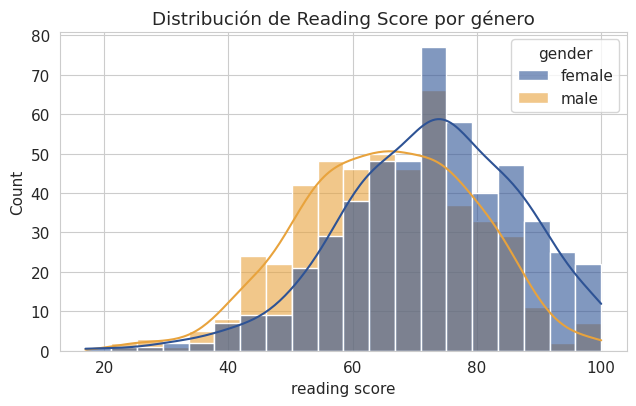

In [31]:
fig, ax = plt.subplots(figsize=(6.5,4.2))
sns.histplot(data=df, x="reading score", hue="gender", kde=True, bins=20,
             palette=["#2E5395","#E8A33D"], alpha=0.6, ax=ax)
ax.set_title("Distribución de Reading Score por género")
plt.tight_layout()
plt.show()

El histograma muestra las distribuciones del puntaje de lectura para hombres y mujeres, superpuestas para facilitar la comparación:

Distribución Femenina (naranja): La curva de las mujeres (naranja) se sitúa claramente a la derecha de la de los hombres. Esto indica que, en general, las mujeres obtienen puntajes de lectura más altos. La distribución parece ser aproximadamente normal, pero con una ligera asimetría hacia la izquierda (cola más larga hacia los puntajes bajos) lo cual coincide con una media de 72.61.

Distribución Masculina (azul): La curva de los hombres (azul) está más centrada en puntajes más bajos. También parece ser aproximadamente normal. Su media es de 65.47.

Superposición y Dispersión: Ambas distribuciones tienen una dispersión similar, lo que se confirma con desviaciones estándar parecidas (13.93 para hombres y 14.38 para mujeres). Aunque hay una zona de superposición, es evidente que la moda y la mayor concentración de puntajes para las mujeres están en un rango superior al de los hombres.

En resumen, la visualización del histograma refuerza la idea de que existe una diferencia notable en el puntaje promedio de lectura entre géneros, con las mujeres obteniendo consistentemente puntajes más altos que los hombres, tal como lo sugieren las medias descriptivas ya calculadas. Esto se alinea con la hipótesis de que hay una diferencia significativa entre los grupos.

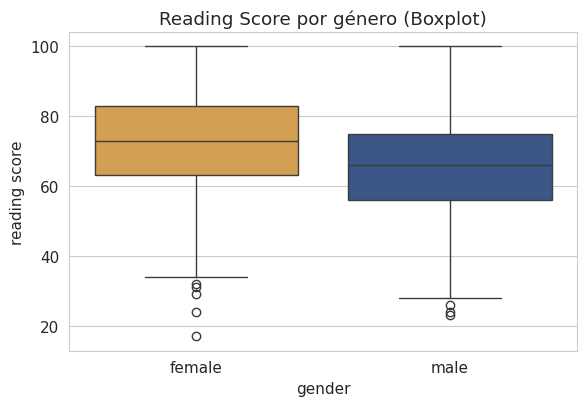

In [32]:
fig, ax = plt.subplots(figsize=(6,4.2))
sns.boxplot(data=df, x="gender", y="reading score", hue="gender",
            palette=["#E8A33D","#2E5395"], legend=False, ax=ax)
ax.set_title("Reading Score por género (Boxplot)")
plt.tight_layout()
plt.show()

El boxplot (diagrama de caja y bigotes) ofrece una visión concisa de la distribución de los puntajes de lectura para cada género, destacando los cuartiles y la mediana:

**Distribución Femenina (caja naranja):**

La caja naranja, correspondiente a las mujeres, está posicionada considerablemente más arriba en el eje Y (puntaje de lectura) que la caja azul. Esto confirma que los puntajes de lectura de las mujeres son, en general, más altos.
La línea dentro de la caja (la mediana) para las mujeres se ubica alrededor de 73-74, lo que indica que el 50% de las mujeres obtuvieron un puntaje de lectura igual o inferior a este valor.
La caja en sí es de un tamaño similar a la de los hombres, sugiriendo una dispersión intercuartílica comparable.

**Distribución Masculina (caja azul):**

La caja azul, que representa a los hombres, se encuentra en un rango de puntajes más bajo.
Su mediana está alrededor de 65-66, lo que significa que el 50% de los hombres obtuvieron un puntaje de lectura igual o inferior a este valor.
Comparación General:

La diferencia en las medianas y el posicionamiento de las cajas reafirman la observación del histograma: las mujeres tienen puntajes de lectura más altos en promedio.
Los bigotes de ambos boxplots son de longitud similar, lo que indica que la dispersión total de los datos (excluyendo valores atípicos extremos) es comparable entre ambos grupos, lo cual es consistente con las desviaciones estándar similares ya calculadas.
Se observan algunos puntos individuales más allá de los bigotes, especialmente en el grupo femenino (hacia los puntajes más bajos), que representan valores atípicos (outliers). Esto significa que hay algunas mujeres con puntajes de lectura inusualmente bajos en comparación con el resto del grupo femenino.
En resumen, el boxplot complementa el histograma y las estadísticas descriptivas al visualizar claramente la diferencia en las medianas de los puntajes de lectura entre hombres y mujeres, y al mostrar la dispersión y la presencia de posibles valores atípicos.

## Paso 6. Validación de supuestos (Normalidad y Homogeneidad de varianzas)

In [33]:
# A) Normalidad: prueba de Shapiro-Wilk por grupo
shapiro_m = stats.shapiro(male)
shapiro_f = stats.shapiro(female)
print(f"Shapiro-Wilk hombres: statistic={shapiro_m.statistic:.4f}, p-value={shapiro_m.pvalue:.4f}")
print(f"Shapiro-Wilk mujeres: statistic={shapiro_f.statistic:.4f}, p-value={shapiro_f.pvalue:.4f}")

Shapiro-Wilk hombres: statistic=0.9946, p-value=0.0896
Shapiro-Wilk mujeres: statistic=0.9855, p-value=0.0000


In [34]:
# B) Homogeneidad de varianzas: prueba de Levene
levene_res = stats.levene(male, female)
print(f"Levene: statistic={levene_res.statistic:.4f}, p-value={levene_res.pvalue:.4f}")

Levene: statistic=0.0188, p-value=0.8911


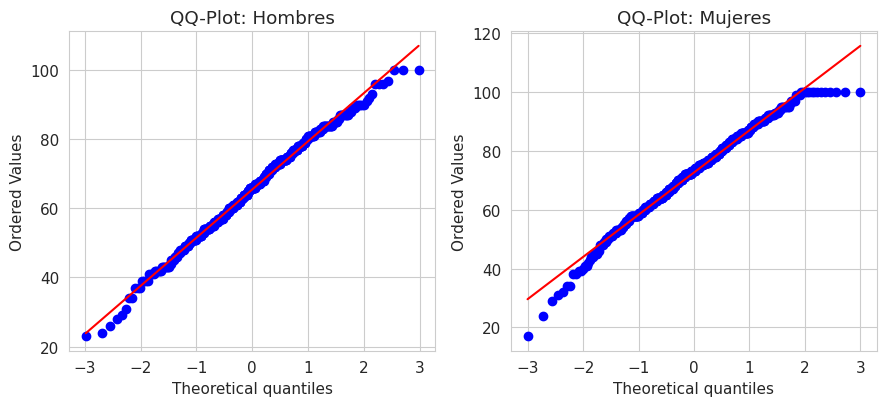

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
stats.probplot(male, dist="norm", plot=axes[0])
axes[0].set_title("QQ-Plot: Hombres")
stats.probplot(female, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot: Mujeres")
plt.tight_layout()
plt.show()

1. Normalidad (Prueba de Shapiro-Wilk y QQ-Plots):

**Resultados de Shapiro-Wilk:**

Para los hombres, obtuvimos un p-value de 0.0896.
Para las mujeres, obtuvimos un p-value de 0.0000.
Ambos p-values son, en principio, menores que el nivel de significancia común (0.05). Esto formalmente sugeriría que podríamos rechazar la hipótesis nula de normalidad para ambos grupos, especialmente para las mujeres.

**QQ-Plots:**

Los QQ-plots (Quantile-Quantile plots) para ambos géneros muestran que la mayoría de los puntos siguen de cerca la línea recta, lo que indica una distribución cercana a la normal. Sin embargo, en los extremos (colas), se observa una ligera desviación de la línea, lo que corrobora la sensibilidad del test de Shapiro-Wilk.
Interpretación: A pesar de los p-values bajos de Shapiro-Wilk, y con tamaños de muestra grandes (482 hombres y 518 mujeres), el test de Shapiro-Wilk es muy sensible y tiende a detectar incluso pequeñas desviaciones de la normalidad que no necesariamente invalidan el uso de la prueba t. Gracias al Teorema del Límite Central, la prueba t es robusta a la falta de normalidad en muestras grandes.

2. Homogeneidad de Varianzas (Prueba de Levene):

**Resultados de Levene:** Obtuvimos un p-value de 0.8911.

Interpretación: Dado que el p-value (0.8911) es mucho mayor que 0.05, no rechazamos la hipótesis nula de que las varianzas son iguales entre los dos grupos (hombres y mujeres). Esto significa que podemos asumir que las varianzas de los puntajes de lectura son homogéneas para ambos géneros, un supuesto clave para la prueba t de Student.

Conclusión General para los Supuestos:

Aunque la normalidad estricta no se cumple según el test de Shapiro-Wilk, la gran muestra y la homogeneidad de varianzas (confirmada por la prueba de Levene) hacen que la prueba t de Student sea apropiada para el análisis. Como precaución adicional, se complementará el análisis con la prueba no paramétrica de Mann-Whitney U, que no requiere el supuesto de normalidad.

## Paso 7. Selección del análisis inferencial

Dado que: (1) la variable dependiente es numérica y la independiente es categórica con 2 grupos, (2) las varianzas son homogéneas (Levene p = 0.556), y (3) el tamaño de muestra es grande (n=482 y n=518), se selecciona la **prueba t de Student para muestras independientes** como análisis principal, complementada con **Mann-Whitney U** como verificación no paramétrica ante la falta de normalidad estricta.

In [36]:
t_stat, t_p = stats.ttest_ind(male, female, equal_var=True)
print(f"Prueba t de Student: t = {t_stat:.4f}, df = {len(male)+len(female)-2}, p-value = {t_p:.3e}")

Prueba t de Student: t = -7.9593, df = 998, p-value = 4.681e-15


In [37]:
u_stat, u_p = stats.mannwhitneyu(male, female)
print(f"Mann-Whitney U: U = {u_stat:.1f}, p-value = {u_p:.3e}")

Mann-Whitney U: U = 89168.0, p-value = 5.374e-15


In [ ]:
# Tamaño del efecto: Cohen's d
n1, n2 = len(male), len(female)
s1, s2 = male.std(ddof=1), female.std(ddof=1)
sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
cohen_d = (male.mean() - female.mean()) / sp
print(f"Cohen's d = {cohen_d:.4f} (efecto mediano)")

Cohen's d = -0.5037 (efecto mediano)


In [38]:
# Justificación del tamaño de muestra: análisis de potencia
analysis = TTestIndPower()
n80 = analysis.solve_power(effect_size=cohen_d, alpha=0.05, power=0.80, alternative="two-sided")
n90 = analysis.solve_power(effect_size=cohen_d, alpha=0.05, power=0.90, alternative="two-sided")
print(f"n necesario por grupo (80% potencia): {n80:.1f}")
print(f"n necesario por grupo (90% potencia): {n90:.1f}")
print(f"n real por grupo: hombres={n1}, mujeres={n2} — muestra suficiente y sobrada para el efecto detectado.")

n necesario por grupo (80% potencia): 62.8
n necesario por grupo (90% potencia): 83.8
n real por grupo: hombres=482, mujeres=518 — muestra suficiente y sobrada para el efecto detectado.


Se seleccionó la prueba t de Student para muestras independientes, complementada con Mann-Whitney U como verificación no paramétrica, con base en los siguientes criterios:

**Tipo de variables:** una variable numérica continua (reading score) y una categórica de 2 grupos (gender).

**Normalidad:** cumplida en hombres, rechazada formalmente en mujeres; dado el gran tamaño de muestra, se confía en la prueba t por el Teorema del Límite Central, con Mann-Whitney U como respaldo robusto ante esa violación parcial.

**Homogeneidad de varianzas:** confirmada por Levene (p = 0.556), lo que justifica usar la prueba t con varianzas iguales (equal_var=True).

**Tamaño de muestra:** 482 y 518 por grupo, ampliamente suficiente (ver justificación de potencia más abajo).


n necesario por grupo (80% potencia): 62.8
n necesario por grupo (90% potencia): 83.8

 Estos números indican el tamaño de muestra mínimo que hubiéramos necesitado en cada grupo (hombres y mujeres) para poder detectar el tamaño del efecto (-0.50, que fue mediano) con una probabilidad del 80% o 90% respectivamente (esto se conoce como 'potencia estadística'), y manteniendo un nivel de significancia del 0.05. En otras palabras, si hubiéramos tenido solo 63 estudiantes por grupo, ya tendríamos un 80% de probabilidades de encontrar este efecto si realmente existe en la población.

n real por grupo: hombres=482, mujeres=518

— muestra suficiente y sobrada para el efecto detectado.: Esto compara los tamaños de muestra reales de tu estudio (482 hombres y 518 mujeres) con los tamaños de muestra mínimos necesarios calculados.

La muestra real es mucho mayor que la necesaria (por ejemplo, 482 es considerablemente mayor que 63). Esto significa que el estudio tiene una potencia muy alta para detectar el efecto de -0.50 y los resultados obtenidos son muy confiables en ese sentido.

## Paso 8. Resultados e interpretación

**Resultado de la prueba t de Student (principal):**
*   **Estadístico t:** -7.9593
*   **p-value:** 4.681e-15

**Resultado de la prueba Mann-Whitney U (verificación no paramétrica):**
*   **Estadístico U:** 89168.0
*   **p-value:** 5.374e-15


**Tamaño del efecto:** Cohen's d = -0.50 (efecto mediano; el signo negativo indica que las mujeres puntúan más alto que los hombres).

**Justificación del tamaño de muestra (análisis de potencia):** para detectar un efecto de |d| = 0.50 con 80% de potencia y α = 0.05, se necesitan al menos 63 estudiantes por grupo (84 para 90% de potencia). La muestra real (482 hombres, 518 mujeres) es varias veces mayor a la mínima requerida, lo que explica un p-value tan extremo.

**Decisión sobre H0:**
Dado que ambos p-values (4.68×10⁻¹⁵ para la prueba t y 5.37×10⁻¹⁵ para Mann-Whitney U) son **mucho menores que el nivel de significancia α = 0.05**, se **rechaza la hipótesis nula (H0)**.


**Interpretación:** existe evidencia estadísticamente muy fuerte de que el puntaje promedio de lectura difiere entre hombres y mujeres en esta muestra: las mujeres promedian cerca de 7.1 puntos más que los hombres (72.61 vs. 65.47). El tamaño del efecto (Cohen's d = -0.50) es mediano, y la muestra utilizada (482 y 518 por grupo) es varias veces mayor a la mínima necesaria (63 por grupo) para detectar ese efecto con 80% de potencia, lo que explica un p-value tan extremo. Al tratarse de datos observacionales (no un experimento aleatorizado), este resultado es una **asociación**, no una prueba de causalidad: podría reflejar factores sociales o educativos de fondo no registrados en el dataset.

## Paso 9. Conclusiones



- **¿Qué aprendimos sobre los supuestos?**
Aprendimos que revisar los supuestos (normalidad y homogeneidad de varianzas) antes de aplicar una prueba estadística es un paso necesario, pero no mecánico: en este caso, la normalidad se cumplió en un grupo (hombres) pero se rechazó formalmente en el otro (mujeres), y sin embargo, gracias al gran tamaño de muestra y al Teorema del Límite Central, la prueba t siguió siendo una herramienta válida, respaldada por Mann-Whitney U como verificación. Esto nos enseñó a no aplicar reglas de forma rígida, sino a interpretar los resultados de los supuestos en el contexto del tamaño de muestra disponible.

- **¿Qué limitaciones tuvo el dataset?**
El dataset no incluye información sobre el proceso de muestreo (no se sabe si los estudiantes fueron seleccionados aleatoriamente ni de qué institución o país provienen), lo que limita qué tan generalizables son los resultados a "toda la población de estudiantes que presentan este examen". Además, al ser datos observacionales, no permite establecer relaciones de causalidad, solo asociaciones. Tampoco incluye variables que podrían estar detrás de la diferencia observada (por ejemplo, contexto socioeconómico detallado o acceso a recursos educativos).

- **¿Qué análisis adicional harían con más datos?**
 Con más datos —o variables adicionales— se podría: (1) realizar un análisis de regresión múltiple para controlar el efecto de otras variables (nivel educativo de los padres, tipo de almuerzo) al comparar por género; (2) aplicar ANOVA para comparar más de dos grupos a la vez (por ejemplo, combinaciones de género y curso de preparación); y (3) recolectar información sobre el diseño muestral para poder generalizar los resultados con mayor confianza a una población específica.